In [1]:
import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from PPRCalculator import PPRCalculator
from ModelData import ModelData

# Other tests

In [2]:
# model_number = 496
# model_number = 240
# model_number = 473
# model_number = 240
model_number = 7
model_number = 105
self = PPRCalculator(model_number)
tls = self.get_TL(break_cycles=False, DET_as_PP=True)
tls
# self.get_groups_df()
# self.GS

51    1.000000
50    1.000000
49    1.000000
48    2.000000
47    2.557895
46    2.000000
45    2.000000
44    2.000000
43    2.000000
42    2.456947
41    2.931141
40    3.084426
39    2.918381
38    3.278947
37    3.962739
36    3.383981
35    3.418421
34    4.079139
33    3.286200
32    3.383691
31    3.195263
30    3.257178
29    4.262008
28    4.039071
27    3.589091
26    3.107302
25    3.280185
24    3.355285
23    3.908335
22    4.284176
21    3.849741
20    3.682842
19    4.000049
18    4.215009
17    3.080570
16    3.021204
15    3.121576
14    4.224592
13    4.382093
12    3.365384
11    3.446879
10    3.621015
9     3.953452
8     3.533849
7     4.280328
6     3.000000
5     4.422608
4     4.125564
3     4.402161
2     4.100458
1     3.313252
dtype: float64

# GS distribution

In [3]:
path = 'real_models/data/'
saved_models = [int(f.split('[')[1].split(']')[0]) for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

In [4]:
gs_list = []
tl_list = []
tl_groups_list = []
trophic_info_list = []
models_list = []
names_list = []

for model_number in tqdm(saved_models):
    # create model calculator:
    try:
        model = PPRCalculator(model_number)
        groups_df = model.get_groups_df()
        groups_df['tl'] = model.get_TL(break_cycles=False, DET_as_PP=True)
        groups_df['gs'] = model.GS.fillna(0)
        groups_df['tl_groups'] = groups_df['tl'].copy()
        groups_df = groups_df[['group_name', 'trophic_info', 'tl', 'tl_groups', 'gs']]
        groups_df.loc[~groups_df['tl_groups'].isin([1, 2]), 'tl_groups'] = 0
        tl_list += groups_df['tl'].tolist()
        tl_groups_list += groups_df['tl_groups'].tolist()
        gs_list += groups_df['gs'].tolist()
        trophic_info_list += groups_df['trophic_info'].tolist()
        names_list += groups_df['group_name'].tolist()
        models_list += [model_number] * len(groups_df)
    except:
        print(model_number)
        continue

  0%|          | 0/119 [00:00<?, ?it/s]

In [5]:
df = pd.DataFrame(data={
    'model_number': models_list,
    'trophic_info': trophic_info_list,
    'group_name': names_list,
    'tl': tl_list,
    'tl_groups': tl_groups_list,
    'gs': gs_list,
})
df

,model_number,trophic_info,group_name,tl,tl_groups,gs
0,105,Import,diet_import,1.000000,1.0,0.0
1,105,DET,Detritus,1.000000,1.0,0.0
2,105,PP,Phytoplankton,1.000000,1.0,0.0
3,105,Regular,S.Zooplankton,2.000000,2.0,0.2
4,105,Regular,L.Zooplankton,2.557895,0.0,0.2
...,...,...,...,...,...,...
3461,7,Regular,Loligo,3.958886,0.0,0.2
3462,7,Regular,large zoopl,2.765306,0.0,0.4
3463,7,Regular,small zoopl,2.000000,2.0,0.4
3464,7,PP,macrophytes,1.000000,1.0,0.0


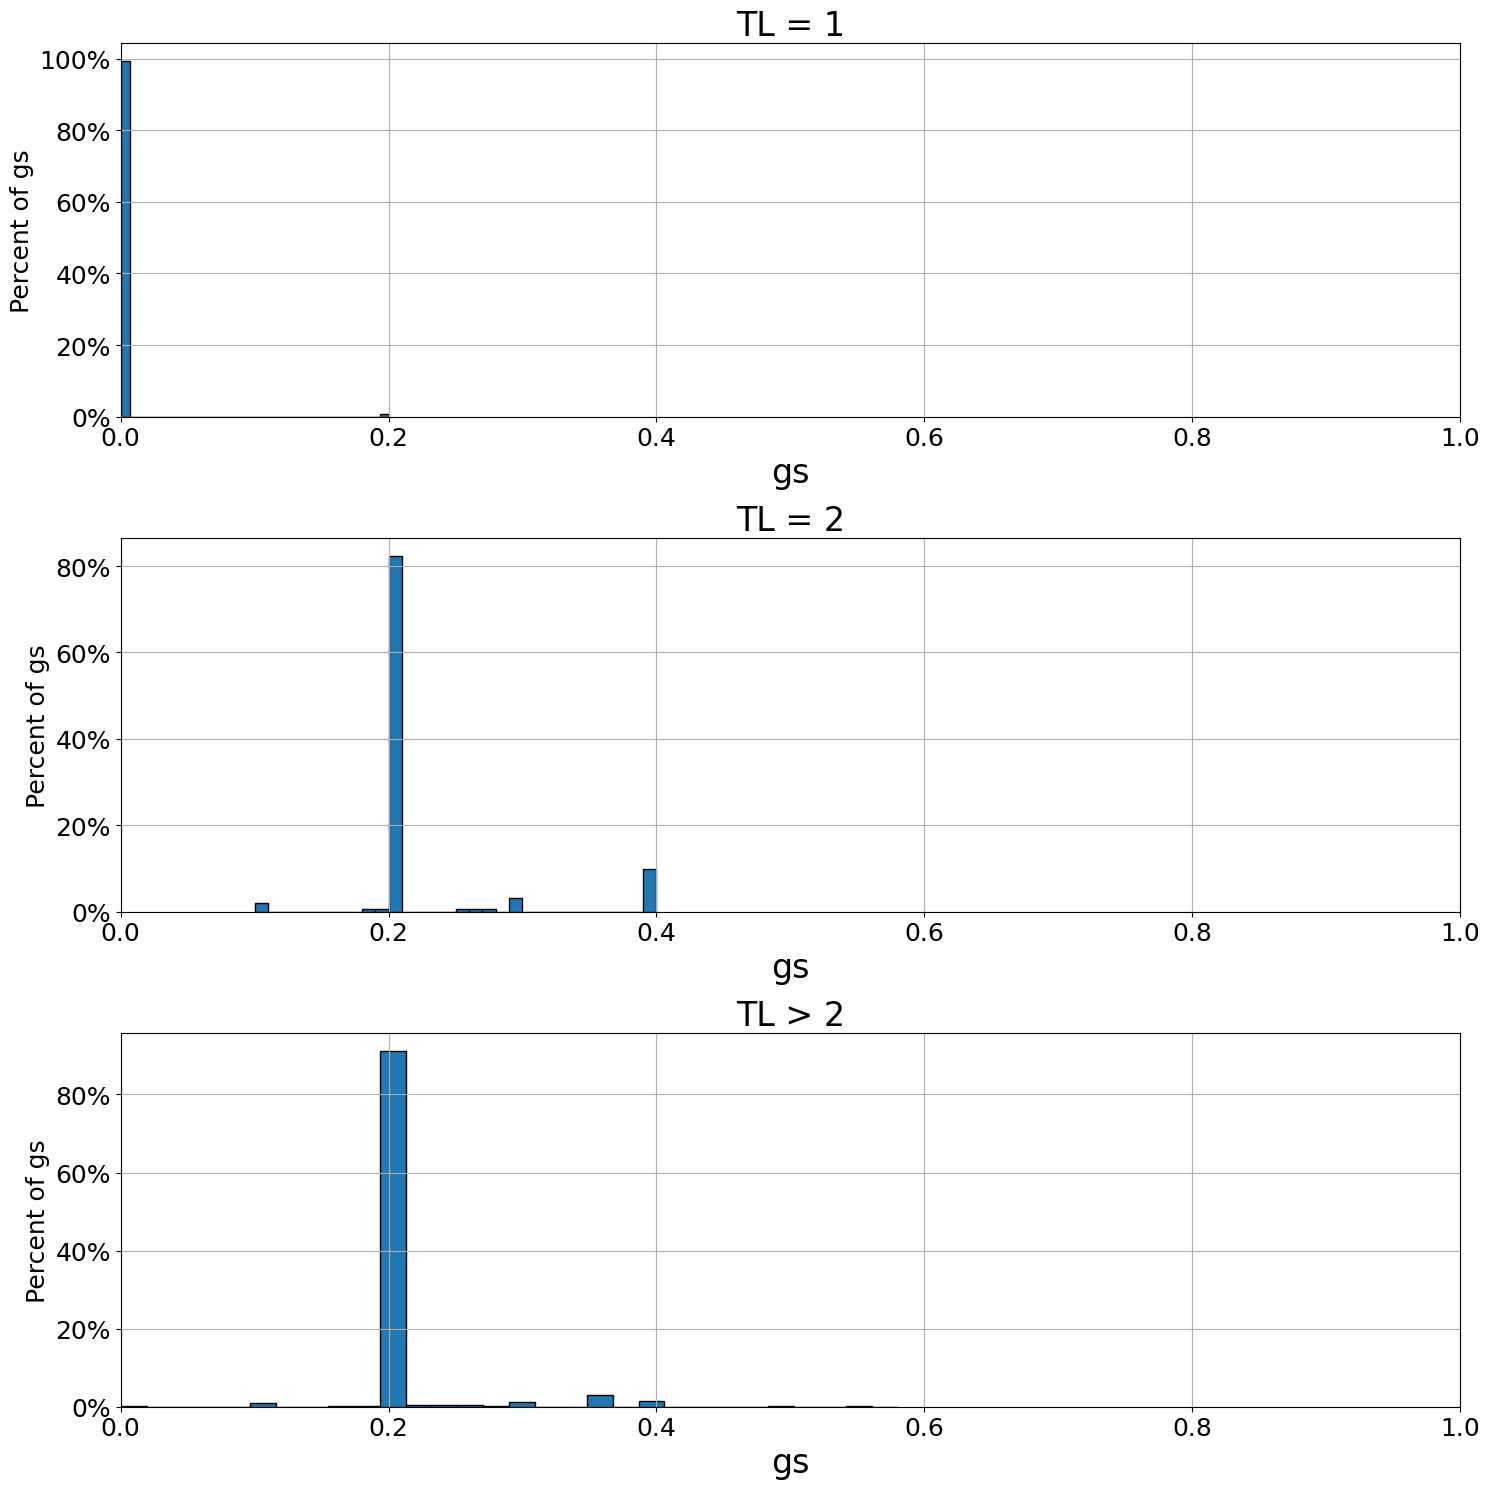

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=False)

for i, tl_value in enumerate([1, 2, 0]):
    subset = df[df["tl_groups"] == tl_value]["gs"].dropna()
    weights = np.ones_like(subset) / len(subset)
    axes[i].hist(subset, bins=30, weights=weights, edgecolor="black")
    if tl_value == 0:
        axes[i].set_title(f"TL > 2", fontsize=24)
    else:
        axes[i].set_title(f"TL = {tl_value}", fontsize=24)
    axes[i].set_xlabel("gs", fontsize=24)
    axes[i].tick_params(axis="both", labelsize=18)
    axes[i].set_ylabel("Percent of gs", fontsize=18)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].set_xlim(0, 1)
    axes[i].grid(True)

fig.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize

def _apply_ecopath_defaults(self, df, zero_biomass_accum=True, default_gs=True):
    """Applies Ecopath defaults and ensures flows are synced with ratios."""

    if "gs" in df.columns:
        is_regular = df["trophic_info"] == "Regular"
        if default_gs:
            df.loc[is_regular, "gs"] = df.loc[is_regular, "gs"].fillna(0.2)
        # PP and Detritus always default to 0
        df.loc[~is_regular, "gs"] = df.loc[~is_regular, "gs"].fillna(0)

    # Sync gs -> egestion
    mask_sync = df["egestion"].isna() & df["q"].notna() & df["gs"].notna()
    df.loc[mask_sync, "egestion"] = df["q"] * df["gs"]

    # Sync ee -> M0
    mask_sync = df["M0"].isna() & df["p"].notna() & df["ee"].notna()
    df.loc[mask_sync, "M0"] = df["p"] * (1 - df["ee"])

    # for DET, M0 is 0 (so ee=1), respiration is 0:
    is_DET = df.get("trophic_info") == "DET"
    df.loc[is_DET, 'M0'] = 0
    df.loc[is_DET, 'respiration'] = 0
    df.loc[is_DET, 'ee'] = 1
    # df.loc[df.get("trophic_info") == "Import", 'respiration'] = 1e-10

    # Handle biomass accumulation and migration
    cols_to_zero = ["net_migration", "immigration", "emmigration"]
    if zero_biomass_accum:
        cols_to_zero.append("biomass_accum")

    for col in cols_to_zero:
        if col in df.columns:
            if col == 'biomass_accum':
                # Detritus often has accumulation; others default to 0
                df.loc[~is_DET, col] = df.loc[~is_DET, col].fillna(0)
            else:
                df[col] = df[col].fillna(0)
    return df

def _solve_lim_model(self, groups_df, force_EE_calculation=True, zero_biomass_accum=True, default_gs=True,
                        solve_cols=['p', 'q', 'respiration', 'egestion', 'M0', 'biomass_accum']):
    def _finalize_ratios(df):
        df['ee'] = (1 - (df['M0'] / df['p'])).replace([np.inf, -np.inf], 1).fillna(1)
        # Ensure gs is 0 for PP/DET
        is_reg = df['trophic_info'] == 'Regular'
        df.loc[is_reg, 'gs'] = (df['egestion'] / df['q']).fillna(0.2)
        df.loc[~is_reg, 'gs'] = 0
        df['ge'] = (df['p'] / df['q']).fillna(0)
        return df

    df = groups_df.copy()

    # 1. Defaults
    df = _apply_ecopath_defaults(self, df, zero_biomass_accum=zero_biomass_accum, default_gs=default_gs)

    # 2. Pre-process ratios
    mask_egest = df["egestion"].isna() & df["q"].notna() & df["gs"].notna()
    df.loc[mask_egest, "egestion"] = df["q"] * df["gs"]

    if force_EE_calculation:
        mask_m0 = df["ee"].notna() & df["p"].notna() & df["M0"].isna()
        df.loc[mask_m0, "M0"] = df["p"] * (1 - df["ee"])

    # 3. Setup Optimization
    valid_flows = ['p', 'q', 'respiration', 'egestion', 'M0', 'biomass_accum']
    solve_cols = [c for c in solve_cols if c in valid_flows]
    if zero_biomass_accum and ('biomass_accum' in solve_cols):
        if 'trophic_info' in df.columns and not (df['trophic_info'] == 'DET').any():
            solve_cols.remove('biomass_accum')
    if default_gs and 'egestion' in solve_cols:
        solve_cols.remove('egestion')
    if ('M0' in solve_cols) and df["M0"].notna().all():
        solve_cols.remove('M0')
    missing_mask = df[solve_cols].isna()

    # Force DET row to be Optimized
    is_DET = df['trophic_info'] == 'DET'
    if is_DET.any():
        for col in ['p', 'q', 'biomass_accum']:
            # Ensure biomass_accum is kept in solve_cols dynamically
            if col not in solve_cols:
                solve_cols.append(col)
                # Re-calculate missing_mask to include the newly appended column
                missing_mask = df[solve_cols].isna()
            if col in ['p', 'q']:
                zero_or_neg = (df[col] <= 0) | df[col].isna()
                df.loc[is_DET & zero_or_neg, col] = 1e-3
            missing_mask.loc[is_DET, col] = True
    
    if missing_mask.sum().sum() == 0:
        return _finalize_ratios(df)
    
    if not zero_biomass_accum:
        missing_mask.loc[:, 'biomass_accum'] = True

    # --- PRE-CACHING STRATEGY FOR HIGH SPEED ---
    trophic_info_arr = df['trophic_info'].values if 'trophic_info' in df.columns else np.array([])
    is_regular_arr = (trophic_info_arr == 'Regular')
    is_import_arr = (trophic_info_arr == 'Import')
    
    # Pull background constant vectors once to avoid checking inside loops
    static_flows = {c: df[c].fillna(0).values for c in ['catch', 'predation', 'net_migration', 'biomass_accum'] if c in df.columns}
    for c in ['catch', 'predation', 'net_migration', 'biomass_accum']:
        if c not in static_flows:
            static_flows[c] = np.zeros(len(df))

    # Store baseline variable states as numpy 1D arrays
    base_arrays = {}
    for col in ['p', 'q', 'respiration', 'egestion', 'M0', 'biomass_accum']:
        base_arrays[col] = df[col].fillna(0).values if col in df.columns else np.zeros(len(df))

    # Build Guess and Bounds
    guess_values, bounds = [], []
    for col in solve_cols:
        nas = missing_mask[col] # Use the adjusted missing_mask here
        if nas.any():
            if col == 'egestion':
                vals = (df['q'] * 0.2).fillna(1.0)[nas].values
            elif col == 'respiration':
                vals = (df['q'] * 0.7).fillna(1.0)[nas].values
                # vals.loc[is_import_arr] = 1e-9
                # vals = vals[nas].values
            elif col == 'M0':
                vals = (df['p'] * 0.1).fillna(1.0)[nas].values
            else:
                if col == 'biomass_accum':
                    # 1. Start with a baseline array of zeros (the safe default for Regular rows)
                    vals = np.zeros(nas.sum())
            
                    # nas is a boolean Series representing rows where biomass_accum is missing
                    missing_indices = df.index[nas]
                    
                    for i, idx in enumerate(missing_indices):
                        if df.loc[idx, 'trophic_info'] == 'DET':
                            # Calculate the mass balance residual: Q - (E + R + Catch + Net_Mig + M0 + Pred)
                            q_val = base_arrays['q'][df.index == idx][0]
                            e_val = base_arrays['egestion'][df.index == idx][0]
                            r_val = base_arrays['respiration'][df.index == idx][0]
                            
                            outflows = (
                                static_flows['catch'][df.index == idx][0] +
                                static_flows['net_migration'][df.index == idx][0] +
                                base_arrays['M0'][df.index == idx][0] +
                                static_flows['predation'][df.index == idx][0]
                            )
                            
                            # Set the guess to the exact missing residual fraction
                            vals[i] = q_val - (e_val + r_val + outflows)
                else:
                    vals = np.full(nas.sum(), 1.0)
            
            guess_values.extend(vals)
            bounds.extend([(None, None) if col == 'biomass_accum' else (1e-10, None)] * nas.sum())

    guess_values = np.array(guess_values)

    # print("respiration in solve_cols:", 'respiration' in solve_cols)
    # print("respiration missing rows:", missing_mask['respiration'].sum() if 'respiration' in missing_mask else "not tracked")

    # Precalculate slice offsets and row indexes for optimized mapping
    col_meta = {}
    curr = 0
    for col in solve_cols:
        nas = missing_mask[col]
        if nas.any():
            n_elements = nas.sum()
            col_meta[col] = {
                'idx': np.where(nas.values)[0],
                'slice': slice(curr, curr + n_elements),
                'any_missing': missing_mask[col].values
            }
            curr += n_elements
    
    # print("col_meta respiration idx:", col_meta.get('respiration', {}).get('idx'))
    # print("missing_mask respiration True rows:", np.where(missing_mask['respiration'].values)[0])
    # print("guess_values length:", len(guess_values))
    # print("bounds length:", len(bounds))
    # total_from_meta = sum(m['slice'].stop - m['slice'].start for m in col_meta.values())
    # print("total vars from col_meta:", total_from_meta)

    # Precalculate active constraint filters
    cons_cols = [c for c in ['q', 'p', 'respiration', 'egestion'] if c in solve_cols]
    prod_cols = [c for c in ['p', 'M0', 'biomass_accum'] if c in solve_cols]
    
    # Row index filters matching exactly your .any() checks
    production_input = df['catch'] + df['predation'] + df['biomass_accum'] + df['net_migration'] + df['M0']
    imbalanced_production = ~np.isclose(df['p'], production_input, atol=1e-5)

    consumption_input = df['p'] + df['respiration'] + df['egestion']
    imbalanced_consumption = ~np.isclose(df['q'], consumption_input, atol=1e-5)

    # Force the constraint filters to be True for these rows
    active_prod_rows = missing_mask[prod_cols].any(axis=1).values | imbalanced_production
    active_cons_rows = missing_mask[cons_cols].any(axis=1).values | imbalanced_consumption
    
    ee_active_rows = np.zeros(len(df), dtype=bool)
    for col in ['p', 'M0']:
        if col in solve_cols:
            ee_active_rows |= missing_mask[col].values

    def get_temp_arrays(x):
        """Generates raw numpy working states quickly without modifying DataFrame memory."""
        arrs = {k: v.copy() for k, v in base_arrays.items()}
        for col, meta in col_meta.items():
            arrs[col][meta['idx']] = x[meta['slice']]
        return arrs

    def get_temp_df(x):
        """Constructs final DataFrame chunk once upon completion."""
        tdf = df.copy()
        for col, meta in col_meta.items():
            tdf.iloc[meta['idx'], tdf.columns.get_loc(col)] = x[meta['slice']]
        return tdf

    # Scale factors - normalize each variable by its guess magnitude
    scale_factors = np.where(np.abs(guess_values) > 1e-8, np.abs(guess_values), 1.0)
    # --- Vectorized Objectives & Constraints ---
    def objective(x):
        arrs = get_temp_arrays(x)
        
        # Term 1: Flow Minimization
        # flow_penalty = np.sum(x**2)
        x_unscaled = x * scale_factors
        scaled_x = x_unscaled / (guess_values + 1e-5)
        flow_penalty = np.sum(scaled_x**2)
        
        # Term 2: GS Deviation Penalty
        gs_penalty = 0
        if 'egestion' in base_arrays and 'q' in base_arrays and len(is_regular_arr) > 0:
            if is_regular_arr.any():
                gs_dev = (arrs['egestion'][is_regular_arr] - 0.2 * arrs['q'][is_regular_arr])
                gs_penalty = np.sum(gs_dev**2)
        
        # Term 3: Initial Guess Fidelity
        guess_penalty = np.sum((x - guess_values)**2)

        return (1.0 * flow_penalty) + (0.0 * gs_penalty) + (0.0 * guess_penalty)

    def equality_constraints(x):
        x_unscaled = x * scale_factors
        arrs = get_temp_arrays(x_unscaled)
        eqs = []
        
        if cons_cols:
            consumer_mask = active_cons_rows
            if consumer_mask.any():
                q_vals = arrs['q'][consumer_mask]
                # Normalize each constraint by the magnitude of q for that row
                scale = np.where(np.abs(q_vals) > 1e-8, np.abs(q_vals), 1.0)
                res = (arrs['q'][consumer_mask] - (
                    arrs['p'][consumer_mask] + 
                    arrs['respiration'][consumer_mask] + 
                    arrs['egestion'][consumer_mask]
                )) / scale
                eqs.extend(res)

        if prod_cols:
            if active_prod_rows.any():
                p_vals = arrs['p'][active_prod_rows]
                scale = np.where(np.abs(p_vals) > 1e-8, np.abs(p_vals), 1.0)
                res = (arrs['p'][active_prod_rows] - (
                    static_flows['catch'][active_prod_rows] + 
                    arrs['M0'][active_prod_rows] + 
                    static_flows['predation'][active_prod_rows] + 
                    static_flows['net_migration'][active_prod_rows] + 
                    arrs['biomass_accum'][active_prod_rows]
                )) / scale
                eqs.extend(res)
                
        return np.array(eqs)

    def inequality_constraints(x):
        x_unscaled = x * scale_factors
        arrs = get_temp_arrays(x_unscaled)
        ineqs = []
        
        # 1. EE <= 1.0 (P - M0 >= 0)
        if ee_active_rows.any():
            p_vals = arrs['p'][ee_active_rows]
            m0_vals = arrs['M0'][ee_active_rows]
            scale = np.where(np.abs(p_vals) > 1e-8, np.abs(p_vals), 1.0)
            ineqs.extend((p_vals - m0_vals) / scale)
        
        # 2. Free GS limits [0.0, 0.4]
        if not default_gs:
            gs_active_mask = (
                is_regular_arr & missing_mask['egestion'].values
                if 'egestion' in missing_mask.columns
                else np.zeros(len(df), dtype=bool)
            )
            if gs_active_mask.any():
                q_vals = arrs['q'][gs_active_mask]
                e_vals = arrs['egestion'][gs_active_mask]
                scale = np.where(np.abs(q_vals) > 1e-8, np.abs(q_vals), 1.0)
                
                gs_low  = (e_vals - 0.0 * q_vals) / scale   # egestion >= 0
                gs_high = (0.4 * q_vals - e_vals) / scale   # egestion <= 0.4*q
                
                ineqs.extend(gs_low)
                ineqs.extend(gs_high)
        
        return np.array(ineqs)

    cons = [
        {'type': 'eq', 'fun': equality_constraints},
        {'type': 'ineq', 'fun': inequality_constraints}
    ]

    # print("solve_cols:", solve_cols)
    # for col in solve_cols:
    #     print(f"  {col}: {missing_mask[col].sum()} missing vars")
    # print("active_cons_rows count:", active_cons_rows.sum())
    # print("active_prod_rows count:", active_prod_rows.sum())
    # print("equality constraints at guess:", equality_constraints(guess_values))

    # Solve in normalized space
    guess_normalized = np.ones(len(guess_values))  # x=1 means "at the guess"
    bounds_normalized = []
    for i, (lo, hi) in enumerate(bounds):
        lo_n = lo / scale_factors[i] if lo is not None else None
        hi_n = hi / scale_factors[i] if hi is not None else None
        bounds_normalized.append((lo_n, hi_n))

    result = minimize(
        objective,
        guess_normalized,
        bounds=bounds_normalized,
        constraints=cons,
        method='SLSQP',
        tol=1e-8,
        options={'maxiter': 2000, 'ftol': 1e-8}
    )

    result.x = result.x * scale_factors

    if result.success:
        return _finalize_ratios(get_temp_df(result.x))
    else:
        # model = self.get_model()
        model = ModelData(459)
        if model is not None:
            print(f"Model {model.model_number} - LIM Failed: {result.message}")
        else:
            print(f"Toy Model - LIM Failed: {result.message}")
        return _finalize_ratios(get_temp_df(result.x))

In [25]:
modeldata = ModelData(459)
# modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan
modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan

groups_df = modeldata.groups_data.copy()
groups_df[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan

groups_df = _solve_lim_model(modeldata, groups_df, zero_biomass_accum=True, default_gs=True)

groups_df.round(5)[['group_name', 'trophic_info', 'tl', 'ee', 'p', 'q', 'biomass_accum', 'net_migration', 'M0', 'predation', 'catch', 'gs', 'egestion', 'respiration']]


solve_cols: ['p', 'q', 'respiration', 'M0', 'biomass_accum']
  p: 2 missing vars
  q: 2 missing vars
  respiration: 31 missing vars
  M0: 1 missing vars
  biomass_accum: 1 missing vars
active_cons_rows count: 32
active_prod_rows count: 3
equality constraints at guess: [ 0.00000000e+00 -1.36960000e+03 -5.58888000e+01 -4.61200000e+02
 -5.33743232e-01 -4.24434322e+00  1.53380749e-04  1.13878800e-04
  0.00000000e+00 -1.97164016e+01 -4.96783976e-01 -1.57935840e+01
  2.51472306e-03 -3.17372116e-01  6.96278940e-03 -7.56160000e-02
  7.08351786e-04 -3.83500000e-03 -3.26540000e-01 -4.47733633e-03
  3.46944695e-18  0.00000000e+00  1.19440000e-05 -2.61825914e-03
  0.00000000e+00  1.12700000e-03  4.37073000e-02  1.49340800e-03
  7.32614400e-03  2.96247330e-02  1.44780000e-03 -1.00000000e+00
  9.99000000e-01  1.15332729e+03  0.00000000e+00]
Model 459 - LIM Failed: Singular matrix C in LSQ subproblem


,group_name,trophic_info,tl,ee,p,q,biomass_accum,net_migration,M0,predation,catch,gs,egestion,respiration
group_seq,,,,,,,,,,,,,,
31,Detritus,DET,1.00000,1.00000,1.00000,1.00000,0.001,0.0,0.00000,NaN,NaN,0.0,NaN,0.00000
30,Phytoplankton,PP,1.00000,0.84209,1369.60000,0.00000,0.000,0.0,216.27271,NaN,NaN,0.0,0.00000,0.00000
29,Large zooplankton,Regular,3.00597,0.15243,83.83320,279.44400,0.000,0.0,71.05464,12.77856,0.00000,0.2,55.88880,195.61080
28,Small zooplankton,Regular,2.00301,0.66559,692.00000,2308.00000,0.000,0.0,231.41099,460.58901,0.00000,0.2,461.60000,1615.60000
27,Large squids,Regular,4.39837,0.35927,0.81460,2.80862,0.000,0.0,0.52194,0.29266,0.00001,0.2,0.56172,1.96603
26,Small squids,Regular,3.86046,0.95000,6.36594,21.21593,0.000,0.0,0.31830,6.04764,0.00000,0.2,4.24319,14.85115
25,Other turtles,Regular,3.50449,0.99000,0.00012,0.00268,0.000,0.0,0.00000,0.00008,0.00003,0.2,0.00054,0.00188
24,Leatherback turtle,Regular,3.98591,0.99000,0.00009,0.00199,0.000,0.0,0.00000,0.00008,0.00001,0.2,0.00040,0.00140
23,Large mesopelagics,Regular,4.01639,0.17684,3.84572,38.45715,0.000,0.0,3.16563,0.68008,0.00000,0.2,7.69143,26.92000


In [7]:
model = PPRCalculator(459)
model.get_groups_df().round(5)[['group_name', 'trophic_info', 'tl', 'ee', 'p', 'q', 'biomass_accum', 'net_migration', 'M0', 'predation', 'catch', 'gs', 'egestion', 'respiration']]
# model.get_PPR(model.SPPR_new(TE_option='TE')[0], only_inner=True).sum(axis=1)

,group_name,trophic_info,tl,ee,p,q,biomass_accum,net_migration,M0,predation,catch,gs,egestion,respiration
group_seq,,,,,,,,,,,,,,
32,diet_import,Import,1.00000,1.00000,84.56694,84.56694,0.00000,0.0,0.00000,84.56694,0.00000,0.0,0.00000,0.00000
31,Detritus,DET,1.00000,0.00000,1642.61581,1642.61581,491.83744,0.0,0.00000,1150.77837,0.00000,0.0,0.00000,0.00000
30,Phytoplankton,PP,1.00000,0.84209,1369.59993,1369.59993,0.00000,0.0,216.27271,1153.32722,0.00000,0.0,0.00000,0.00000
29,Large zooplankton,Regular,3.00597,0.15243,83.83320,279.44400,0.00000,0.0,71.05464,12.77856,0.00000,0.4,111.77760,83.83320
28,Small zooplankton,Regular,2.00301,0.66559,692.00000,2308.00000,0.00000,0.0,231.41099,460.58901,0.00000,0.4,923.20000,692.80000
27,Large squids,Regular,4.39837,0.35927,0.81460,2.80862,0.00000,0.0,0.52194,0.29266,0.00001,0.2,0.56172,1.43229
26,Small squids,Regular,3.86046,0.95000,6.36594,21.21593,0.00000,0.0,0.31830,6.04764,0.00000,0.2,4.24319,10.60681
25,Other turtles,Regular,3.50449,0.99000,0.00012,0.00268,0.00000,0.0,0.00000,0.00008,0.00003,0.2,0.00054,0.00203
24,Leatherback turtle,Regular,3.98591,0.99000,0.00009,0.00199,0.00000,0.0,0.00000,0.00008,0.00001,0.2,0.00040,0.00151


In [ ]:
modeldata = ModelData(459)
# modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan
modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan
model = PPRCalculator.from_modeldata(modeldata, underdetermined=True, zero_biomass_accum=True, default_gs=True,
                                      solve_cols=['p', 'q', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration'])
                                        # solve_cols=['p', 'q', 'egestion', 'respiration'])
model.get_groups_df().round(5)[['group_name', 'trophic_info', 'tl', 'ee', 'p', 'q', 'biomass_accum', 'net_migration', 'M0', 'predation', 'catch', 'gs', 'egestion', 'respiration']]

# model.get_PPR(model.SPPR_new(TE_option='TE')[0], only_inner=True).sum(axis=1)

Model 459 - LIM Failed: Singular matrix C in LSQ subproblem


,group_name,trophic_info,tl,ee,p,q,biomass_accum,net_migration,M0,predation,catch,gs,egestion,respiration
group_seq,,,,,,,,,,,,,,
32,diet_import,Import,1.00000,1.00000,84.56694,84.56694,0.00000,0.0,0.00000,84.56694,0.00000,0.0,0.00000,1.00000
31,Detritus,DET,1.00000,1.00000,1125.12701,1125.12701,-25.65136,0.0,0.00000,1150.77837,0.00000,0.0,0.00000,0.00000
30,Phytoplankton,PP,1.00000,0.84209,1369.59993,1369.59993,0.00000,0.0,216.27271,1153.32722,0.00000,0.0,0.00000,0.00000
29,Large zooplankton,Regular,3.00597,0.15243,83.83320,279.44400,0.00000,0.0,71.05464,12.77856,0.00000,0.2,55.88880,195.61080
28,Small zooplankton,Regular,2.00301,0.66559,692.00000,2308.00000,0.00000,0.0,231.41099,460.58901,0.00000,0.2,461.60000,1615.60000
27,Large squids,Regular,4.39837,0.35927,0.81460,2.80862,0.00000,0.0,0.52194,0.29266,0.00001,0.2,0.56172,1.96603
26,Small squids,Regular,3.86046,0.95000,6.36594,21.21593,0.00000,0.0,0.31830,6.04764,0.00000,0.2,4.24319,14.85115
25,Other turtles,Regular,3.50449,0.99000,0.00012,0.00268,0.00000,0.0,0.00000,0.00008,0.00003,0.2,0.00054,0.00188
24,Leatherback turtle,Regular,3.98591,0.99000,0.00009,0.00199,0.00000,0.0,0.00000,0.00008,0.00001,0.2,0.00040,0.00140


In [9]:
model_numbers_non_default = [108,
 116,
 125,
 145,
 153,
 168,
 172,
 217,
 218,
 227,
 232,
 269,
 282,
 311,
 312,
 410,
 413,
 459,
 462,
 464,
 473,
 485,
 487,
 488,
 497,
 499,
 500,
 501,
 502,
 503,
 504,
 505,
 506,
 520,
 633,
 634,
 646,
 650,
 651,
 654,
 658,
 680,
 687,
 689,
 725,
 726,
 7]

In [10]:
balanced, p, q = model.is_model_balanced()
d = pd.DataFrame({
    'p': p,
    'model_p': model.p,
    'q': q,
    'model_q': model.q,
}).rename(index=model.seq2name)
d

,p,model_p,q,model_q
group_seq,,,,
diet_import,84.566940,84.566940,85.566940,84.566940
Detritus,1125.127013,1125.127013,1125.127013,1125.127013
Phytoplankton,1369.599930,1369.599930,1369.599930,1369.599930
Large zooplankton,83.833200,83.833200,335.332800,279.444000
Small zooplankton,692.000000,692.000000,2769.200000,2308.000000
Large squids,0.814605,0.814605,3.342359,2.808616
Small squids,6.365936,6.365936,25.460272,21.215929
Other turtles,0.000115,0.000115,0.002531,0.002684
Leatherback turtle,0.000085,0.000085,0.001879,0.001993


In [12]:
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# model_numbers_non_default = df.loc[~df["gs"].isin([0, 0.2]), "model_number"].unique().tolist()

results = {
    'model_number': [],
    'is_gs_default': [],
    'SPPR_1986': [],
    'SPPR_1995': [],
    'SPPR_new_TE': [],
    'SPPR_new_GE': [],
    # 'SPPR_EwE': [],
    # 'SPPR_2015': [],
}

for model_number in tqdm(saved_models):
    # index:
    results['model_number'].append(model_number)
    results['is_gs_default'].append(model_number not in model_numbers_non_default)

    # full data:
    model = PPRCalculator(model_number)
    results['SPPR_1986'].append(model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())
    results['SPPR_1995'].append(model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())
    results['SPPR_new_TE'].append(model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())
    results['SPPR_new_GE'].append(model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())
    # results['SPPR_EwE'].append(model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum())
    # results['SPPR_2015'].append(model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())

    # partial data:
    modeldata = ModelData(model_number)
    # modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan
    modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum']] = np.nan
    # modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan
    model = PPRCalculator.from_modeldata(modeldata, underdetermined=True, zero_biomass_accum=True, default_gs=True,
                                        #   solve_cols=['p', 'q', 'egestion', 'respiration', 'biomass_accum', 'net_migration'])
                                          solve_cols=['p', 'q', 'egestion', 'respiration', 'biomass_accum'])
    results['SPPR_1986'][-1] = abs((results['SPPR_1986'][-1] - model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())) / results['SPPR_1986'][-1]
    results['SPPR_1995'][-1] = abs((results['SPPR_1995'][-1] - model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())) / results['SPPR_1995'][-1]
    results['SPPR_new_TE'][-1] = abs((results['SPPR_new_TE'][-1] - model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_TE'][-1]
    results['SPPR_new_GE'][-1] = abs((results['SPPR_new_GE'][-1] - model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_GE'][-1]
    # results['SPPR_EwE'][-1] = (results['SPPR_EwE'][-1] - model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum()) / results['SPPR_EwE'][-1]
    # results['SPPR_2015'][-1] = abs((results['SPPR_2015'][-1] - model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_2015'][-1]

df_results = pd.DataFrame(results)

  0%|          | 0/119 [00:00<?, ?it/s]

Model 105 - LIM Failed: Singular matrix C in LSQ subproblem
Model 107 - LIM Failed: Singular matrix C in LSQ subproblem
Model 108 - LIM Failed: Singular matrix C in LSQ subproblem
Model 111 - LIM Failed: Singular matrix C in LSQ subproblem
Model 112 - LIM Failed: Singular matrix C in LSQ subproblem
Model 115 - LIM Failed: More equality constraints than independent variables
Model 116 - LIM Failed: Singular matrix C in LSQ subproblem
Model 118 - LIM Failed: Singular matrix C in LSQ subproblem
Model 125 - LIM Failed: Singular matrix C in LSQ subproblem
Model 135 - LIM Failed: Singular matrix C in LSQ subproblem
Model 136 - LIM Failed: Singular matrix C in LSQ subproblem
Model 137 - LIM Failed: Singular matrix C in LSQ subproblem
Model 145 - LIM Failed: Singular matrix C in LSQ subproblem
Model 153 - LIM Failed: More equality constraints than independent variables
Model 168 - LIM Failed: More equality constraints than independent variables
Model 172 - LIM Failed: Singular matrix C in LSQ 

In [35]:
df_results

,model_number,is_gs_default,SPPR_1986,SPPR_1995,SPPR_new_TE,SPPR_new_GE
0,105,True,0.0,0.0,0.000000,0.000000
1,107,True,0.0,0.0,0.000000,0.000000
2,108,False,0.0,0.0,0.063741,0.467039
3,111,True,0.0,0.0,0.000000,0.000000
4,112,True,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...
114,692,True,0.0,0.0,0.000000,0.000000
115,693,True,0.0,0.0,0.000000,0.000000
116,725,False,0.0,0.0,0.039416,0.471416
117,726,False,0.0,0.0,0.028830,1.261744


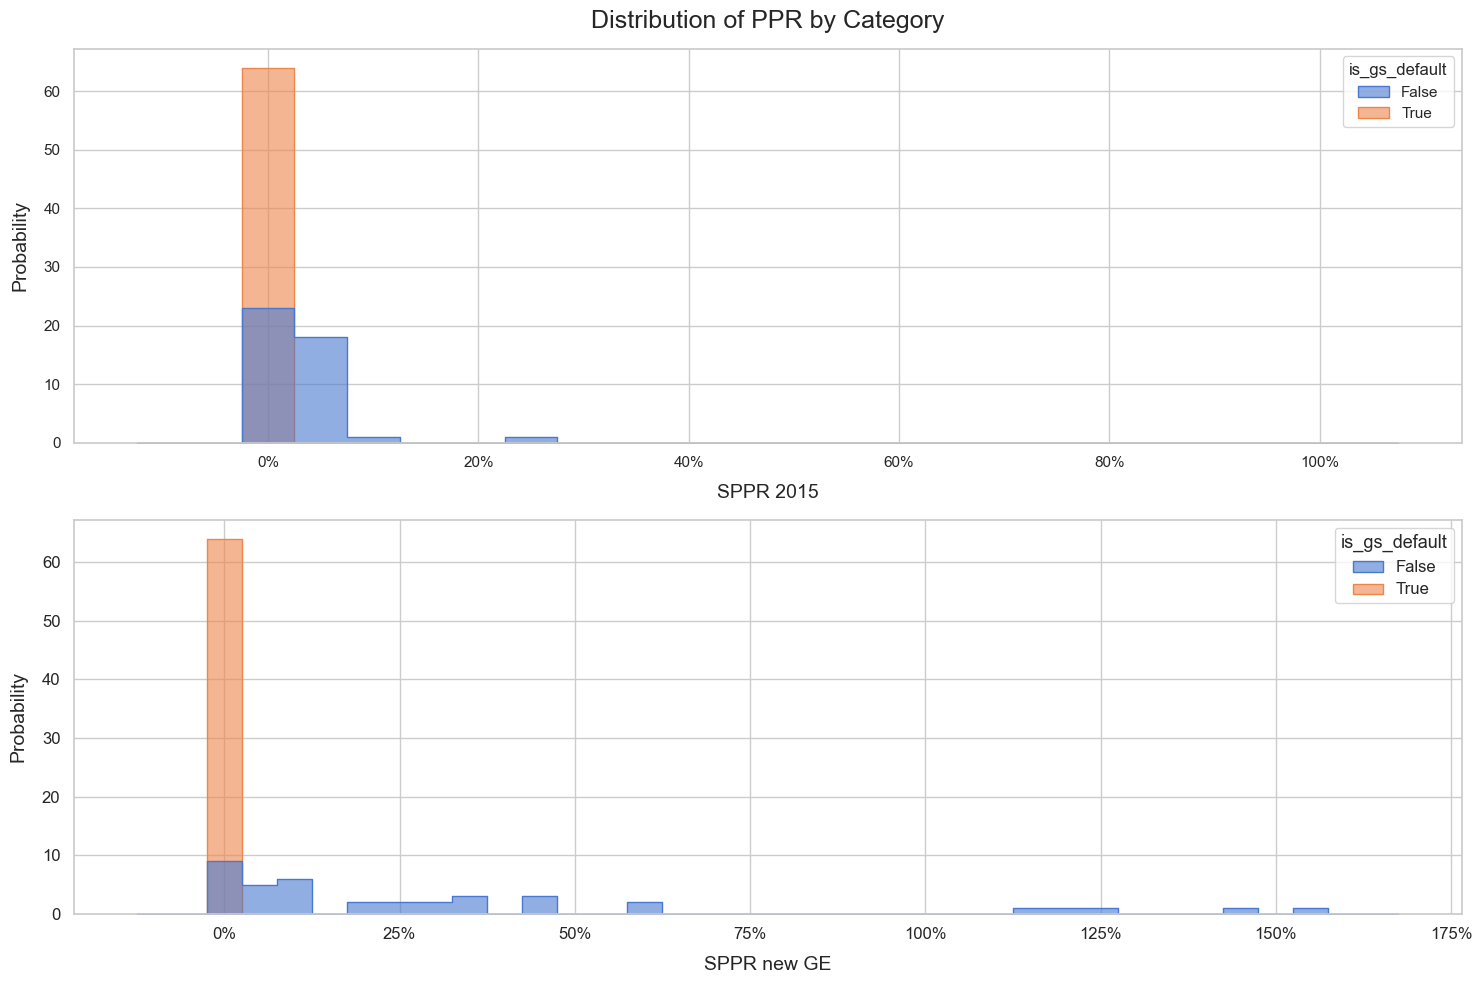

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


df_viz = df_results.copy()
df_viz['SPPR_new_TE'] *= 100
df_viz['SPPR_new_GE'] *= 100

# Set a clean background style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_TE",
    # bins=30,
    bins=np.arange(-12.5, 112.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[0]
)

# Customize titles and labels with big fonts
ax.set_title("Distribution of PPR by Category", fontsize=18, pad=15)
ax.set_xlabel("SPPR 2015", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_GE",
    # bins=30,
    bins=np.arange(-12.5, 172.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[1]
)

# Customize titles and labels with big fonts
ax.set_xlabel("SPPR new GE", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Make axis tick marks larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make the legend text larger
plt.setp(ax.get_legend().get_texts(), fontsize="12")
plt.setp(ax.get_legend().get_title(), fontsize="13")

# Adjust spacing and display
plt.tight_layout()
plt.show()

In [ ]:
def _apply_ecopath_defaults(self, df, zero_biomass_accum=True, default_gs=True):
    """Applies Ecopath defaults and ensures flows are synced with ratios."""

    if "gs" in df.columns:
        is_regular = df["trophic_info"] == "Regular"
        if default_gs:
            df.loc[is_regular, "gs"] = df.loc[is_regular, "gs"].fillna(0.2)
        # PP and Detritus always default to 0
        df.loc[~is_regular, "gs"] = df.loc[~is_regular, "gs"].fillna(0)

    # Sync gs -> egestion
    mask_sync = df["egestion"].isna() & df["q"].notna() & df["gs"].notna()
    df.loc[mask_sync, "egestion"] = df["q"] * df["gs"]

    # Sync ee -> M0
    mask_sync = df["M0"].isna() & df["p"].notna() & df["ee"].notna()
    df.loc[mask_sync, "M0"] = df["p"] * (1 - df["ee"])

    # for DET, M0 is 0 (so ee=1):
    is_DET = df.get("trophic_info") == "DET"
    df.loc[is_DET, 'M0'] = 0
    df.loc[is_DET, 'ee'] = 1

    # Handle biomass accumulation and migration
    cols_to_zero = ["net_migration", "immigration", "emmigration"]
    if zero_biomass_accum:
        cols_to_zero.append("biomass_accum")

    for col in cols_to_zero:
        if col in df.columns:
            if col == 'biomass_accum':
                # Detritus often has accumulation; others default to 0
                df.loc[~is_DET, col] = df.loc[~is_DET, col].fillna(0)
            else:
                df[col] = df[col].fillna(0)
    return df

def _solve_lim_model(self, groups_df, force_EE_calculation=True, zero_biomass_accum=True, default_gs=True,
                        solve_cols=['p', 'q', 'respiration', 'egestion', 'M0', 'biomass_accum']):
    def _finalize_ratios(df):
        df['ee'] = (1 - (df['M0'] / df['p'])).replace([np.inf, -np.inf], 1).fillna(1)
        # Ensure gs is 0 for PP/DET
        is_reg = df['trophic_info'] == 'Regular'
        df.loc[is_reg, 'gs'] = (df['egestion'] / df['q']).fillna(0.2)
        df.loc[~is_reg, 'gs'] = 0
        df['ge'] = (df['p'] / df['q']).fillna(0)
        return df

    df = groups_df.copy()

    # 1. Defaults
    df = self._apply_ecopath_defaults(df, zero_biomass_accum=zero_biomass_accum, default_gs=default_gs)

    # 2. Pre-process ratios
    mask_egest = df["egestion"].isna() & df["q"].notna() & df["gs"].notna()
    df.loc[mask_egest, "egestion"] = df["q"] * df["gs"]

    if force_EE_calculation:
        mask_m0 = df["ee"].notna() & df["p"].notna() & df["M0"].isna()
        df.loc[mask_m0, "M0"] = df["p"] * (1 - df["ee"])

    # 3. Setup Optimization
    valid_flows = ['p', 'q', 'respiration', 'egestion', 'M0', 'biomass_accum']
    solve_cols = [c for c in solve_cols if c in valid_flows]
    if zero_biomass_accum and ('biomass_accum' in solve_cols):
        solve_cols.remove('biomass_accum')
    if default_gs and 'egestion' in solve_cols:
        solve_cols.remove('egestion')
    if ('M0' in solve_cols) and df["M0"].notna().all():
        solve_cols.remove('M0')
    missing_mask = df[solve_cols].isna()

    # FORCE DETRITUS Row TO BE OPTIMIZED
    if 'trophic_info' in df.columns:
        is_DET = df['trophic_info'] == 'DET'
        if is_DET.any():
            # Loop through the columns you want to optimize for DET (e.g., 'p' and 'q')
            for col in ['p', 'q']:
                if col in solve_cols:
                    # Force the mask to True for the DET row so the solver targets it
                    missing_mask.loc[is_DET, col] = True
    
    if missing_mask.sum().sum() == 0:
        return _finalize_ratios(df)

    # Build Guess and Bounds
    guess_values, bounds = [], []
    for col in solve_cols:
        nas = df[col].isna()
        if nas.any():
        # if nas.all():
            if col == 'egestion':
                vals = (df['q'] * 0.2).fillna(1.0)[nas].values
            elif col == 'respiration':
                vals = (df['q'] * 0.7).fillna(1.0)[nas].values
            elif col == 'M0':
                vals = (df['p'] * 0.1).fillna(1.0)[nas].values
            else:
                vals = np.full(nas.sum(), 0.0 if col == 'biomass_accum' else 1.0)
            
            guess_values.extend(vals)
            bounds.extend([(None, None) if col == 'biomass_accum' else (1e-10, None)] * nas.sum())

    def get_temp_df(x):
        tdf = df.copy()
        curr = 0
        for col in solve_cols:
            nas = tdf[col].isna()
            if nas.any():
                tdf.loc[nas, col] = x[curr:curr+nas.sum()]
                curr += nas.sum()
        return tdf

    # def objective(x):
    #     return np.sum(x**2)
    
    def objective(x):
        tdf = get_temp_df(x)
        
        # --- Term 1: Flow Minimization ---
        flow_penalty = np.sum(x**2)
        
        # --- Term 2: GS Deviation Penalty ---
        gs_penalty = 0
        # Safely check if columns exist before calculating
        if 'egestion' in tdf.columns and 'q' in tdf.columns and 'trophic_info' in tdf.columns:
            is_reg = tdf['trophic_info'] == 'Regular'
            if is_reg.any():
                gs_dev = (tdf.loc[is_reg, 'egestion'] - 0.2 * tdf.loc[is_reg, 'q'])
                gs_penalty = np.sum(gs_dev**2)
        
        # --- Term 3: Initial Guess Fidelity ---
        guess_penalty = np.sum((x - guess_values)**2)

        return (1.0 * flow_penalty) + (0.0 * gs_penalty) + (0.0 * guess_penalty)

    def equality_constraints(x):
        tdf = get_temp_df(x)
        eqs = []
        
        # Dynamically find which columns actually exist in the mask to avoid KeyErrors
        cons_cols = [c for c in ['q', 'p', 'respiration', 'egestion'] if c in solve_cols]
        prod_cols = [c for c in ['p', 'M0', 'biomass_accum'] if c in solve_cols]

        for i, row in tdf.iterrows():
            # 1. Consumption Balance
            if row.get('trophic_info') == 'Regular':
                # Check if this row has unknowns in the existing cons_cols
                if cons_cols and missing_mask.loc[i, cons_cols].any():
                    # .get() safely pulls the value, or defaults to 0 if the column doesn't exist
                    q = row.get('q', 0)
                    p = row.get('p', 0)
                    r = row.get('respiration', 0)
                    e = row.get('egestion', 0)
                    eqs.append(q - (p + r + e))
            
            # 2. Production Balance
            if prod_cols and missing_mask.loc[i, prod_cols].any():
                p = row.get('p', 0)
                catch = row.get('catch', 0)
                m0 = row.get('M0', 0)
                pred = row.get('predation', 0)
                nm = row.get('net_migration', 0)
                ba = row.get('biomass_accum', 0)
                eqs.append(p - (catch + m0 + pred + nm + ba))
                
        return np.array(eqs)

    def inequality_constraints(x):
        tdf = get_temp_df(x)
        ineqs = []
        
        # 1. EE <= 1.0 (P - M0 >= 0)
        # Use .get with a default Series of 0s to prevent crashes on whole columns
        for i, row in tdf.iterrows():
            if ('p' in solve_cols and missing_mask.loc[i, 'p']) or ('M0' in solve_cols and missing_mask.loc[i, 'M0']):
                p = row.get('p', 0)
                m0 = row.get('M0', 0)
                ineqs.append(p - m0)
        
        # 2. Free GS limits [0.0, 0.4]
        if not default_gs:
            if 'trophic_info' in tdf.columns:
                is_reg = tdf['trophic_info'] == 'Regular'
                if is_reg.any():
                    q_vals = tdf.loc[is_reg].get('q', 0)
                    e_vals = tdf.loc[is_reg].get('egestion', 0)
                    
                    # Lower: E - 0.0*Q >= 0 | Upper: 0.4*Q - E >= 0
                    gs_low = e_vals - 0.0 * q_vals
                    gs_high = 0.4 * q_vals - e_vals
                    
                    ineqs.extend(gs_low.values)
                    ineqs.extend(gs_high.values)
            
        return np.array(ineqs)

    cons = [
        {'type': 'eq', 'fun': equality_constraints},
        {'type': 'ineq', 'fun': inequality_constraints}
    ]

    result = minimize(objective, np.array(guess_values), bounds=bounds, 
                    constraints=cons, method='SLSQP', options={'maxiter': 1000})

    if result.success:
        return _finalize_ratios(get_temp_df(result.x))
    else:
        print(f"LIM Failed: {result.message}")
        return _finalize_ratios(get_temp_df(result.x))